100%|██████████| 9.91M/9.91M [00:12<00:00, 781kB/s] 
100%|██████████| 28.9k/28.9k [00:01<00:00, 15.0kB/s]
100%|██████████| 1.65M/1.65M [03:05<00:00, 8.87kB/s]
100%|██████████| 4.54k/4.54k [00:01<00:00, 4.03kB/s]


训练集大小：60000
测试集大小：60000
图片形状：torch.Size([1, 28, 28])
图片batch形状: torch.Size([32, 1, 28, 28])
标签batch形状: torch.Size([32])


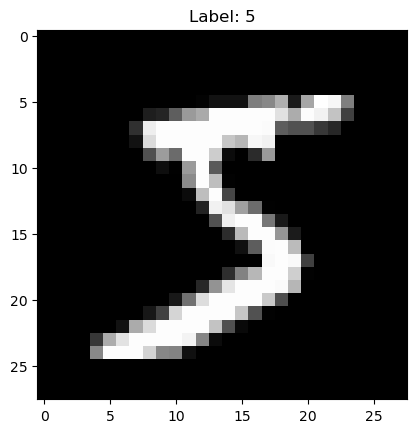

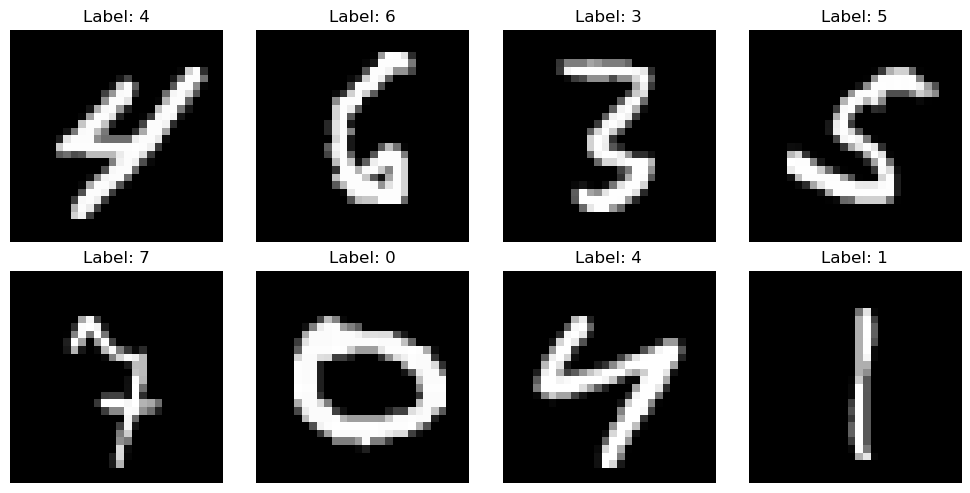

In [ ]:
import torch#主库，用于张量运算
import torchvision#计算机视觉库，内置数据收集，模型，图像变换
import torchvision.transforms as transforms#transforms 图像预处理工具，裁剪，旋转，标准化
from torch.utils.data import DataLoader#数据加载器，批量读取数据
import matplotlib.pyplot as plt#绘图库，展示图片

#transforms.Compose:把多个预处理步骤打包成一个流水线，按顺序执行
transform=transforms.Compose([
    transforms.ToTensor(),#把PIL图片转换成PyTorch张量
    #张量形状从(H,W,C)变成(C,H,W)
    #像素值从[0,255]缩放到【0.0，1.0】

    #标准化公式(x-mean)/std
    #效果：把[0,1]的像素值映射到[-1,1]
    #标准化:让数据分布更均匀，帮助神经网络更快收敛
    #注意彩图要传三个值
    transforms.Normalize((0.5,),(0.5,))
])

train_dataset=torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset=torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)


print(f"训练集大小：{len(train_dataset)}")
print(f"测试集大小：{len(test_dataset)}")
print(f"图片形状：{train_dataset[0][0].shape}")

train_loader=DataLoader(
    train_dataset,
    batch_size=32,#每批32张图
    shuffle=True#打乱顺序
)


test_loader=DataLoader(
    test_dataset,
    batch_size=32,#每批32张图
    shuffle=False#打乱顺序
)

# 5. 查看一个batch的数据
images,labels=next(iter(train_loader))#把DataLoader转成迭代器
print(f"图片batch形状:{images.shape}") # [32, 1, 28, 28]
print(f"标签batch形状:{labels.shape}") # [32]

# 6. 可视化一张图片
image=train_dataset[0][0].squeeze()  # 去掉维度1
plt.imshow(image,cmap='gray')#灰度映射
plt.title(f"Label:{train_dataset[0][1]}")
plt.show()

# 7. 可视化一个batch的前8张图
fig,axes=plt.subplots(2,4,figsize=(10, 5))
for i,ax in enumerate(axes.flat):
    img=images[i].squeeze()
    ax.imshow(img,cmap='gray')
    ax.set_title(f"Label:{labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()
